# Notebook for plotting additional canonical evolution Figures A1 and A3 
## Preamble
### Load packages required

In [1]:
#SJL 6/2020
#Script to plot the change in surface length for planets in the canonical model


###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import h5py

import scipy.integrate as integrate
from scipy.optimize import curve_fit

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')


/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Set parameters and select bodies to plot

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#number of contor lines
Ncont=20


## Main script
### Either calculate the tidal evolution and change in length or read in the pre-calculated data

In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

if flag_calc==1:
    Hdatabase=HERCULES_random_planet_database_1D()
    Hdatabase.make_array(Hdir,Hname)
    Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,[],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)
    
    #extract the latitudes for each Mu point
    Nmu=Hdatabase.parr[0].Nmu
    lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

    #only Ltot is held constant
    Ltot=LEM
    
    #k2Q array
    Nk2Q=100
    k2Q=np.logspace(-5,0,Nk2Q)
    
    #time array
    t=np.asarray([0.0,0.1,1,10,100])*const.year*1E6
    Nt=np.size(t)
    
    #a0 array
    a0=np.asarray([2.9,5,10])*REarth
    Na0=np.size(a0)
    
                
    #run through and extract orbital elements, lengths and areas at each time point
    a=np.zeros((Nt,Na0,Nk2Q))
    L=np.zeros((Nt,Na0,Nk2Q))
    
    dLdt=np.zeros((Nt,Na0,Nk2Q))
    
    dl_lat=np.empty((Nt,Na0,Nk2Q,Nmu))
    dl_lon=np.empty((Nt,Na0,Nk2Q,Nmu))
    dA=np.empty((Nt,Na0,Nk2Q,Nmu))
    
    ddl_lat_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))
    ddl_lon_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))
    ddA_dL=np.zeros((Nt,Na0,Nk2Q,Nmu))
    
    ddl_lat_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))
    ddl_lon_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))
    ddA_dt=np.zeros((Nt,Na0,Nk2Q,Nmu))
    
    
    for kk in np.arange(Na0): 
        print(kk+1,'/',Na0)
        for i in np.arange(Nk2Q):
            print('\t',i,'/',Nk2Q)
    
            #calculate the orbit
            kappa=3.0*k2Q[i]*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
            a[:,kk,i]=((13.0/2.0)*(kappa*t+(2.0/13.0)*(a0[kk]**(13.0/2.0))))**(2.0/13.0)
            L[:,kk,i]=Ltot-(MMoon)*np.sqrt(const.G*a[:,kk,i]*(MEarth+MMoon))
            dLdt[:,kk,i]=-0.5*MMoon/np.sqrt(const.G*a[:,kk,i]*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a[:,kk,i]**(-11.0/2.0))
    
            
            for j in np.arange(Nt):
    
                # print('\t\t',j,'/',Nt)
    
                temp_data=Hdatabase.interp_database(L[j,kk,i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                                   [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
                temp=np.asarray(temp_data[16])
    
                dl_lat[j,kk,i,:]=temp[:,0]
                dl_lon[j,kk,i,:]=temp[:,1]
                dA[j,kk,i,:]=temp[:,2]
    
                ddl_lat_dL[j,kk,i,:]=temp[:,3]*np.pi/180.0
                ddl_lon_dL[j,kk,i,:]=temp[:,4]*np.pi/180.0
                ddA_dL[j,kk,i,:]=temp[:,5]*(np.pi/180.0)**2
    
                ddl_lat_dt[j,kk,i,:]=temp[:,3]*dLdt[j,kk,i]*np.pi/180.0
                ddl_lon_dt[j,kk,i,:]=temp[:,4]*dLdt[j,kk,i]*np.pi/180.0
                ddA_dt[j,kk,i,:]=temp[:,5]*dLdt[j,kk,i]*(np.pi/180.0)**2

    #activate if you want to reprint the run data
    if 1==0:
        # np.savez('Data/FigureA1andA3', Nmu=Nmu, lat=lat, k2Q=k2Q, a0=a0, Ltot=Ltot, Nt=Nt, t=t, kappa=kappa, a=a, L=L, \
        #          ddl_lat_dt=ddl_lat_dt, ddl_lon_dt=ddl_lon_dt, ddA_dt=ddA_dt)

        print('Overwriting existing data file')
        
        hdf5_file = "Data/FigureA1andA3.h5"
        
        Nchunk=256
        
        with h5py.File(hdf5_file, "w") as h5:
        
            Na0=np.size(a0)
            Nk2Q=np.size(k2Q)
        
            # Scalars
            for name, val in zip(["Nmu", "Ltot", "Nt", "Na0", "Nk2Q"],
                                 [Nmu, Ltot, Nt,Na0, Nk2Q]):
                h5.create_dataset(name, data=np.array(val))
        
            # 1D arrays
            for name, arr in zip(["a0","lat", "t", "k2Q"], [a0,lat, t, k2Q]):
                h5.create_dataset(name, data=arr.astype(np.float64),
                                  dtype=np.float64,
                                  compression="gzip",
                                  compression_opts=4,
                                  shuffle=True,
                                  chunks=(min(Nchunk, len(arr)),))
        
            # 3D arrays
            for name, arr in zip(["a", "L"], [a, L]):
                h5.create_dataset(
                    name,
                    data=arr.astype(np.float64),
                    dtype=np.float32,
                    compression="gzip",
                    compression_opts=4,
                    shuffle=True,
                    chunks=(min(Nchunk, Nt), Na0, Nk2Q)
                )
        
            # 4D arrays
            for name, arr in zip(["ddl_lat_dt", "ddl_lon_dt", "ddA_dt"], [ddl_lat_dt, ddl_lon_dt, ddA_dt]):
                h5.create_dataset(
                    name,
                    data=arr.astype(np.float64),
                    dtype=np.float32,
                    compression="gzip",
                    compression_opts=4,
                    shuffle=True,
                    chunks=(min(Nchunk, Nt), Na0, Nk2Q, Nmu)
                )
        
        
        
        print("HDF5 file written.")
                        
                
else:

    print('Reading in surface change data')
    hdf5_file = "Data/FigureA1andA3.h5"
    
    # --------------------------------------------------
    # HDF5 reader
    # --------------------------------------------------
    with h5py.File(hdf5_file, "r") as h5:
        # Scalars
        Nmu      = int(h5["Nmu"][()])
        Ltot     = h5["Ltot"][()]
        Nt       = int(h5["Nt"][()])
        Na0       = int(h5["Na0"][()])
        Nk2Q       = int(h5["Nk2Q"][()])
    
        # 1D arrays
        a0       = h5["a0"][:]
        lat      = h5["lat"][:]
        t        = h5["t"][:]
        k2Q    = h5["k2Q"][:]
    
        # 3D arrays
        a        = h5["a"][:]
        L        = h5["L"][:]
    
        # 4D arrays
        ddl_lat_dt = h5["ddl_lat_dt"][:]
        ddl_lon_dt = h5["ddl_lon_dt"][:]
        ddA_dt     = h5["ddA_dt"][:]
    
    print("All variables read back successfully.")

    kappa=3.0*k2Q[-1]*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))


print('done')

Reading in surface change data
All variables read back successfully.
done


### Construct Figure A1

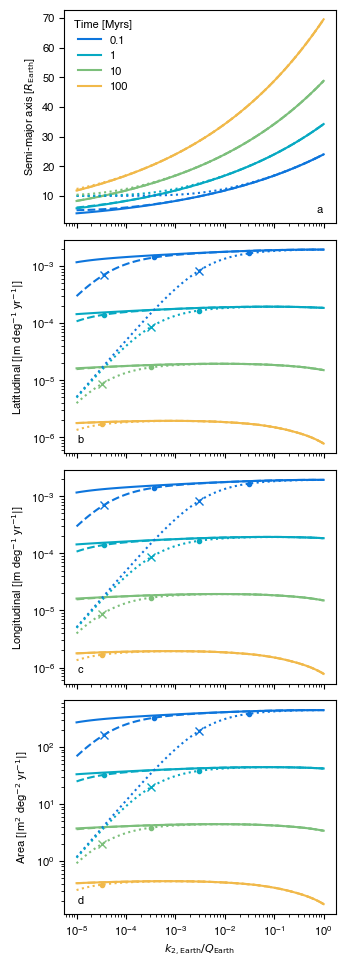

In [8]:
#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('FigureA1.pdf')
mpl.pyplot.close(fig)

#plot the publication quality figure
#initialise the figure
fig = plt.figure(figsize=(3.5,9.724))
#fig = plt.figure(figsize=(3.5,25))
gs = gridspec.GridSpec(4, 1)

ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[1]))
ax[0].append(plt.subplot(gs[2]))
ax[0].append(plt.subplot(gs[3]))

indmu=0

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

labels=['0.0','0.1','1','10','100']

lines=['-','--',':']
col=cmaps.parula(np.linspace(0,0.8,Nt))

for kk in np.arange(Na0):
    for i in np.arange(Nt)[1:]:
        if kk==0:
            ax[0][0].plot(k2Q,a[i,kk,:]/REarth,lines[kk],color=col[i],label=labels[i])
        else:
            ax[0][0].plot(k2Q,a[i,kk,:]/REarth,lines[kk],color=col[i])
        
        ax[0][1].plot(k2Q,np.absolute(ddl_lat_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        ax[0][2].plot(k2Q,np.absolute(ddl_lon_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        ax[0][3].plot(k2Q,np.absolute(ddA_dt[i,kk,:,indmu])*const.year,lines[kk],color=col[i])
        
        #plot points where the transition time is reached
        temp=(39.0/2.0)*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))*t[i]/(a0[kk]**(13.0/2.0))
        ind=np.where(temp<1)[0]
        if (np.size(ind)>1):
            ind=ind[-1]
            ax[0][1].plot(k2Q[ind],np.absolute(ddl_lat_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            ax[0][2].plot(k2Q[ind],np.absolute(ddl_lon_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            ax[0][3].plot(k2Q[ind],np.absolute(ddA_dt[i,kk,ind,indmu])*const.year,'x',color=col[i])
            
        ind=np.where(temp<10)[0]
        if np.size(ind)>1:
            ind=ind[-1]
            ax[0][1].plot(k2Q[ind],np.absolute(ddl_lat_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
            ax[0][2].plot(k2Q[ind],np.absolute(ddl_lon_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
            ax[0][3].plot(k2Q[ind],np.absolute(ddA_dt[i,kk,ind,indmu])*const.year,'.',color=col[i])
 
ax[0][0].legend(frameon=False, title='Time [Myrs]')
    
for i in np.arange(4):
    if i!=0:
        ax[0][i].set_yscale('log')
    ax[0][i].set_xscale('log')

    if i!=3:
        plt.setp( ax[0][i].get_xticklabels(), visible=False)
 
ax[0][0].set_ylabel(r'Semi-major axis [$R_\mathrm{Earth}$]')
ax[0][1].set_ylabel(r'Latitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][2].set_ylabel(r'Longitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][3].set_ylabel(r'Area [$|$m$^2$ deg$^{-2}$ yr$^{-1}$$|$]')

ax[0][3].set_xlabel(r'$k_{2,\mathrm{Earth}}/Q_\mathrm{Earth}$')

#label axis
ax[0][0].text(0.95, 0.04, 'a', horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.04, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.05, 0.04, 'c', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.05, 0.04, 'd', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')



fig.tight_layout()
plt.savefig('FigureA1.pdf')


### Calculate the transition time and make grid to plot

In [9]:
###########################################################################################
###########################################################################################
###########################################################################################
#plot contours of the transition time

#initial a
Na0_tr=100
a0_tr=np.linspace(2.9,10,Na0_tr)*REarth

#k2/Q
Nk2Q_tr=101
k2Q_tr=np.logspace(-5,0,Nk2Q_tr)

#run and find the transition times
t_transition=np.zeros((Na0_tr,Nk2Q_tr))

for kk in np.arange(Na0_tr): 
    
    t_transition[kk,:]=(a0_tr[kk]**(13.0/2.0))/((39.0/2.0)*k2Q_tr*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon)))
      
print('done')

done


In [10]:
#make contours of the transition ratios
#calculate the interpolation hulls
k2Q_grid=np.linspace(np.log10(k2Q_tr[0]), np.log10(k2Q_tr[-1]), Ncont)
a0_grid=np.linspace(a0_tr[0], a0_tr[-1],Ncont+1)

KKK, RRR = np.meshgrid(k2Q_grid,a0_grid)

temp=np.ones(np.shape(t_transition[:,:]))
k2Q_arr=temp*np.log10(k2Q_tr[None,:])
a0_arr=temp*a0_tr[:,None]



TTT1=griddata(((k2Q_arr.flatten(),a0_arr.flatten())),np.log10(t_transition/const.year).flatten(),(KKK,RRR), method='linear')


print('done')

done


### Construct Figure A3

begin
done


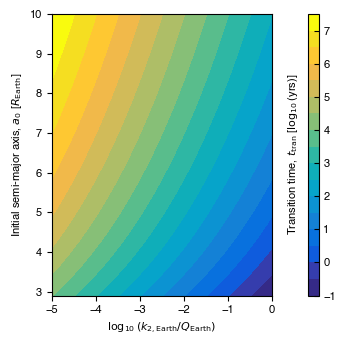

In [11]:
print('begin')

#plot a publication-quality figure

#initialise the figure
fig = plt.figure(figsize=(3.5,3.5))
gs = gridspec.GridSpec(1, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)
  
t_contours=np.linspace(-1,7.5,18) 

contour0 = ax[0][0].contourf(KKK, RRR/REarth, TTT1, levels=t_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(t_contours)-1)))

ax[0][0].set_xlabel(r"$\log_{10} \left ( k_{2,\mathrm{Earth}}/Q_\mathrm{Earth} \right )$")
ax[0][0].set_ylabel(r"Initial semi-major axis, $a_0$ [$R_\mathrm{Earth}$]")

cbar0=plt.colorbar(contour0, cax=ax_col[0][0], orientation='vertical')#,ticks=Alabels)

cbar0.set_label(r'Transition time, $t_\mathrm{tran}$ [$\log_{10}$(yrs)]', labelpad=-36)

ax_col[0][0].tick_params(direction="in")

fig.tight_layout()
plt.savefig('FigureA3.pdf')

print('done')